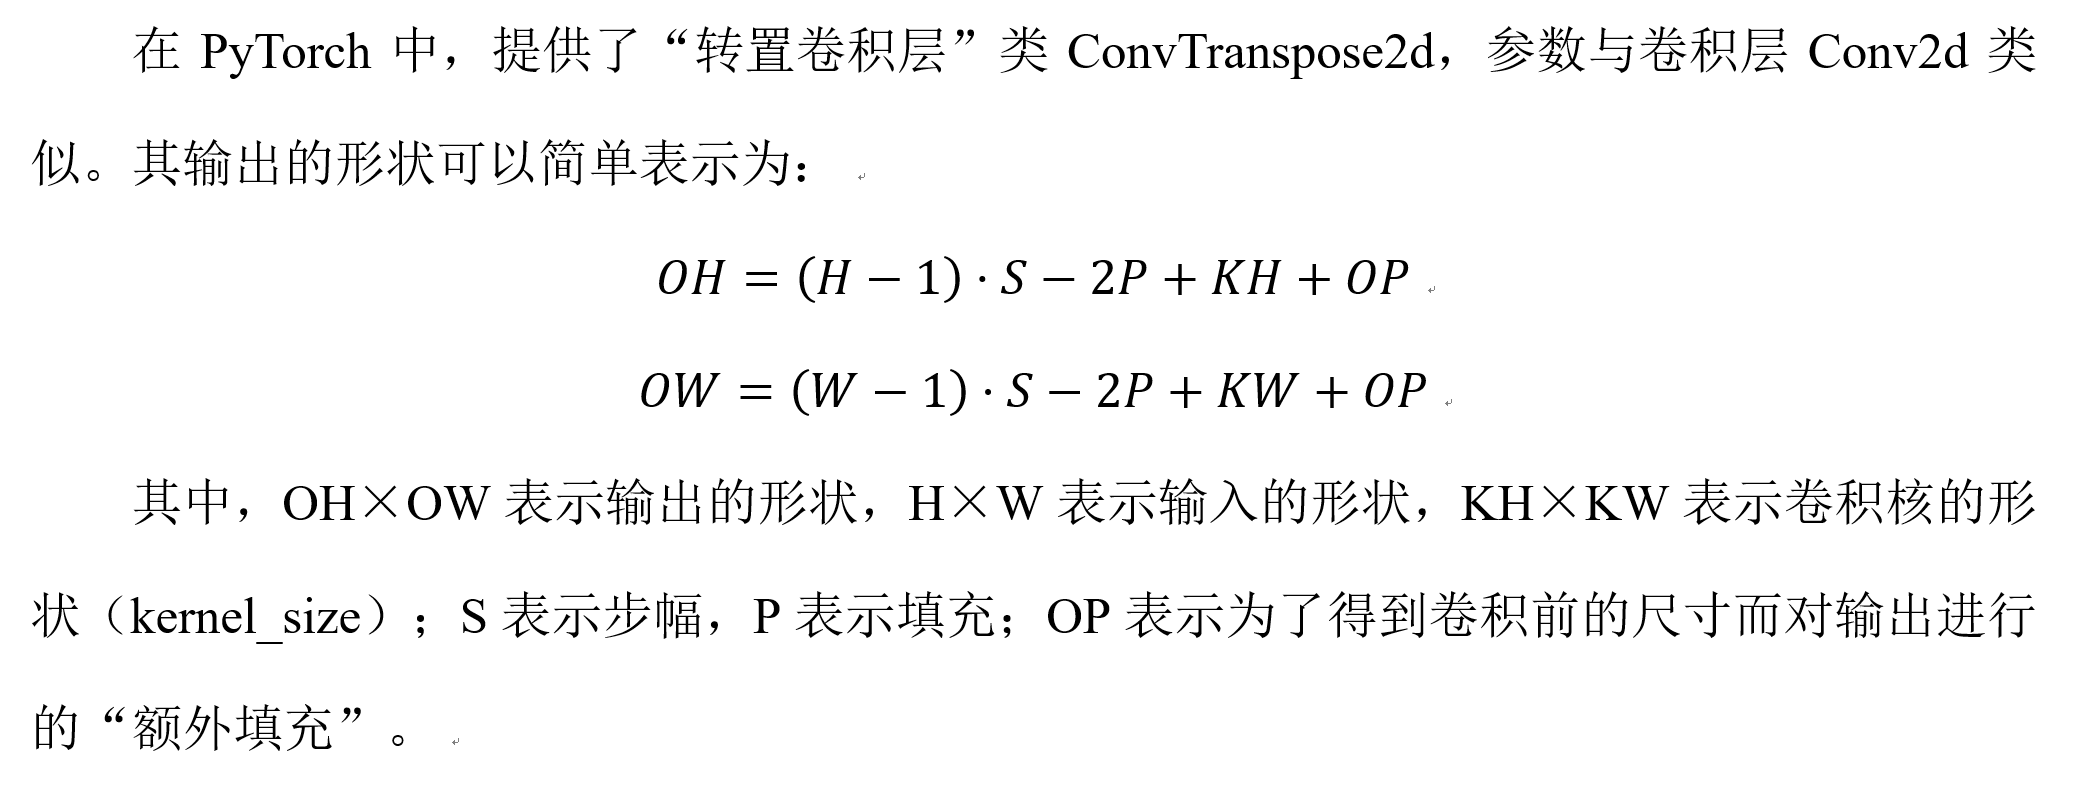

In [ ]:
from typing import Any

import matplotlib.pyplot as plt
from PIL.Image import open as pil_open
from torch import rand, randn, device, cuda, save, load, no_grad, rand_like
from torch.nn import Module, Conv2d, ReLU, MaxPool2d, ConvTranspose2d, Sigmoid, Linear, Flatten, MSELoss, Sequential
from torch.optim import SGD, Adam
from torchvision.transforms import Compose, Resize, ToTensor
from tqdm import tqdm

## 1. 读取图片并进行预处理

### 1.1 读取图片

In [ ]:
image = pil_open(fp="../data/apple.jpg", mode="r")                   # 读取图片
print(image)

### 1.2 将图片转为 tensor

In [ ]:
resize = Resize(size=(256, 256))                                     # 调整图片大小
transforms = [resize, ToTensor()]                                    # 定义转换操作
image_transform = Compose(transforms=transforms)                     # 创建转换操作

image_tensor = image_transform(image)                                # 将图片转为 tensor
print(f"转换后的图： {image_tensor}")
print(f"转换后的图片形状： {image_tensor.shape}")

### 1.3 转为 ndarray，方便打印显示

In [ ]:
reshape=(1, 2, 0)
image_array = image_tensor.numpy().transpose(reshape)
print(image_array.shape)

plt.imshow(image_array)

## 2. 创建自编码器

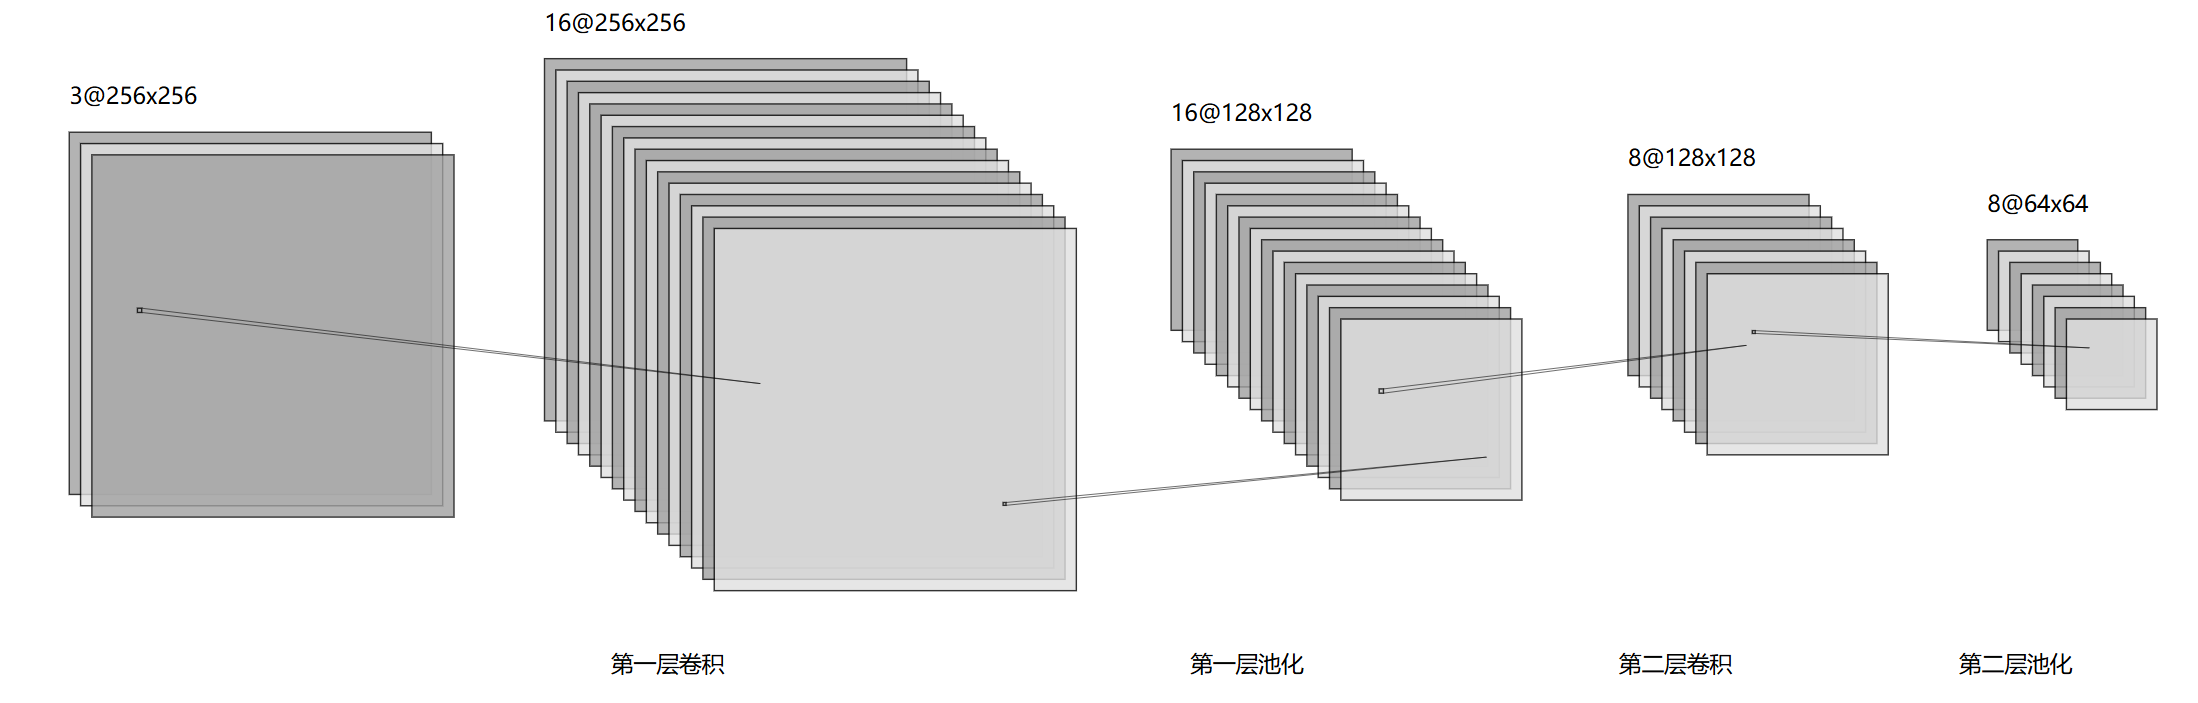

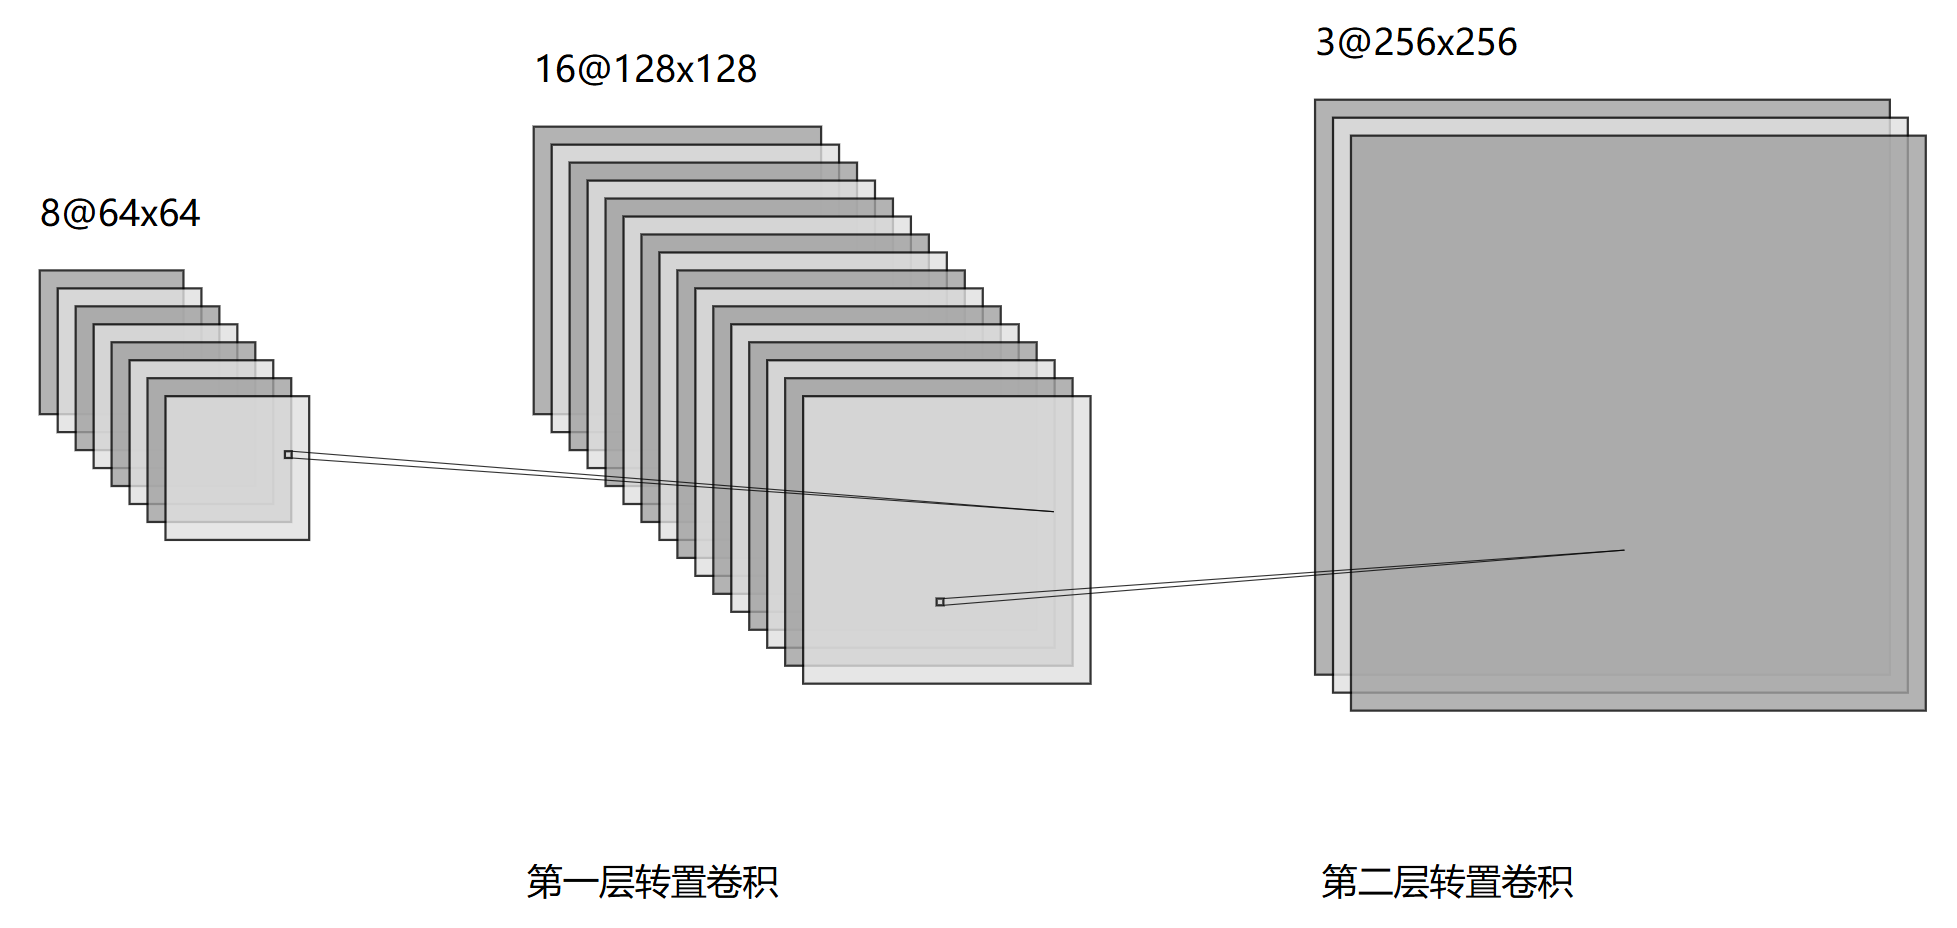

### 2.1 定义自编码器类 AutoEncoder

In [ ]:
class AutoEncoder(Module):
    def __init__(self):
        super().__init__()

        encoder_conv1 = Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1)
        encoder_act1 = ReLU()
        encoder_pool1 = MaxPool2d(kernel_size=2, stride=2, padding=0)

        encoder_conv2 = Conv2d(in_channels=16, out_channels=8, kernel_size=3, stride=1, padding=1)
        encoder_act2 = ReLU()
        encoder_pool2 = MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.encoder = Sequential(encoder_conv1, encoder_act1, encoder_pool1, encoder_conv2, encoder_act2, encoder_pool2)

        decoder_conv1 = ConvTranspose2d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1)
        decoder_act3 = ReLU()

        decoder_conv2 = ConvTranspose2d(in_channels=16, out_channels=3, kernel_size=3, stride=2, padding=1, output_padding=1)
        decoder_act4 = Sigmoid()

        self.decoder = Sequential(decoder_conv1, decoder_act3,decoder_conv2, decoder_act4)

    def forward(self, input_data):
        encoded = self.encoder.forward(input=input_data)
        decoded = self.decoder.forward(input=encoded)
        # print(f"encoded shape: {encoded.shape}")
        # print(f"decoded shape: {decoded.shape}")
        return decoded

### 2.2 测试定义的模型

In [ ]:
model = AutoEncoder()
input_data = randn(1, 3, 256, 256)
output_data = model.forward(input_data)
print(f"输出形状：{output_data.shape}")

## 3. 模型训练

### 3.1 初始化模型和超参数

In [ ]:
DEVICE = device("cuda" if cuda.is_available() else "cpu")            # 定义设备
learning_rate = 0.003                                                # 定义学习率
epochs = 500                                                         # 定义训练轮数
model_path = "../data/auto-encoder.pth"                              # 定义模型保存路径

model = AutoEncoder()                                                # 创建模型实例
model.to(DEVICE)                                                     # 将模型移动到指定设备
loss_fn = MSELoss()                                                  # 定义损失函数
optimizer = Adam(params=model.parameters(), lr=learning_rate)        # 定义优化器

### 3.2 训练模型

In [ ]:
bar = tqdm(iterable=range(epochs), desc="Training", unit="epoch", total=epochs, ncols=100, colour="green")
for epoch in bar:
    image_tensor = image_tensor.to(device=DEVICE)                    # 将输入数据移动到指定设备
    output_tensor = model.forward(input_data=image_tensor)           # 前向传播
    loss_value = loss_fn(output_tensor, image_tensor)                # 计算损失
    loss_value.backward()                                            # 反向传播
    optimizer.step()                                                 # 更新参数
    optimizer.zero_grad()                                            # 清空梯度
    
    bar.set_postfix(loss=loss_value)                                 # 更新进度条
    if epoch % 50 == 0:
        print(f"loss：{loss_value}")

save(obj=model.state_dict(), f=model_path)
print(f"模型保存成功，保存在 {model_path}")

## 4. 推理，重构图像

In [ ]:
model = AutoEncoder()
state_dict = load(f=model_path)
model.load_state_dict(state_dict=state_dict)

with no_grad():
    input_data = image_tensor.to(device=DEVICE)
    output_data = model.forward(input_data=input_data)

image_array = output_data.permute(1, 2, 0).cpu().numpy()
plt.imshow(image_array)
plt.show()

## 5. 去噪声测试

### 5.1 在原始的图片上，添加噪声

In [ ]:
noise_data = image_tensor + rand_like(input=image_tensor) * 0.5
noise_array = noise_data.permute(1, 2, 0).cpu().numpy()
plt.imshow(noise_array)

### 5.2 重新训练

In [ ]:
noisy_model = AutoEncoder()
noisy_model.to(DEVICE)

bar = tqdm(iterable=range(epochs), desc="Training", unit="epoch", total=epochs, ncols=100, colour="green")
for epoch in bar:
    noisy_image_tensor = noise_data.to(device=DEVICE)  # 将输入数据移动到指定设备
    output_tensor = noisy_model.forward(input_data=noisy_image_tensor)  # 前向传播
    loss_value = loss_fn(output_tensor, image_tensor)  # 计算损失
    loss_value.backward()  # 反向传播
    optimizer.step()  # 更新参数
    optimizer.zero_grad()  # 清空梯度

    bar.set_postfix(loss=loss_value)  # 更新进度条
    if epoch % 50 == 0:
        print(f"loss：{loss_value}")

### 5.3 重新推理

In [ ]:
with no_grad():
    input_data = noise_data.to(device=DEVICE)
    output_data = noisy_model.forward(input_data=input_data)

image_array = output_data.permute(1, 2, 0).cpu().numpy()
plt.imshow(image_array)
plt.show()